# Data Science Competition

## Install Dependencies

In [ ]:
%pip install numpy pandas scikit-learn lightgbm shap matplotlib seaborn joblib tqdm

In [ ]:
# ============================================================
# CELL 1 — IMPORTS & GLOBAL CONFIGURATION
# ============================================================

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import shap
import joblib
from math import ceil
from tqdm import tqdm
from sklearn import __version__ as sklearn_version
from sklearn.model_selection import (
    train_test_split, RepeatedKFold, learning_curve
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings('ignore')

# ── Global constants ──────────────────────────────────────────────────────────
DATA_PATH    = 'dataset.csv'         # ← ubah sesuai nama file CSV
TARGET_COL   = 'nama_kolom_target'   # ← ubah sesuai nama kolom target
RANDOM_STATE = 42
K_FOLDS      = 10
N_REPEATS    = 3
TEST_SIZE    = 0.2
SEP          = "=" * 62

# ── Style ─────────────────────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Blues_r')

# ── Print environment info ────────────────────────────────────────────────────
print(SEP)
print("  ENVIRONMENT READY")
print(SEP)
print(f"  NumPy    : {np.__version__}")
print(f"  Pandas   : {pd.__version__}")
print(f"  Sklearn  : {sklearn_version}")
print(f"  LightGBM : {lgb.__version__}")
print(f"  SHAP     : {shap.__version__}")
print(SEP)

  ENVIRONMENT READY
  NumPy    : 2.4.5
  Pandas   : 3.0.3
  Sklearn  : 1.8.0
  LightGBM : 4.6.0
  SHAP     : 0.52.0
  Output   : outputs/


In [ ]:
# ============================================================
# CELL 2 — DATA LOADING
# ============================================================

df = pd.read_csv(DATA_PATH)
FEATURE_COLS = [c for c in df.columns if c != TARGET_COL]

print(SEP)
print("  DATA LOADING")
print(SEP)
print(f"  File     : {DATA_PATH}")
print(f"  Shape    : {df.shape}")
print(f"  Target   : {TARGET_COL}")
print(f"  Features : {len(FEATURE_COLS)} kolom")
print(SEP)

display(df.head())

  DATA LOADING
  File     : flood.csv
  Shape    : (50000, 21)
  Target   : FloodProbability
  Features : 20 kolom


,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,Encroachments,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
0,3,8,6,6,4,4,6,2,3,2,...,10,7,4,2,3,4,3,2,6,0.450
1,8,4,5,7,7,9,1,5,5,4,...,9,2,6,2,1,1,9,1,3,0.475
2,3,10,4,1,7,5,4,7,4,9,...,7,4,4,8,6,1,8,3,6,0.515
3,4,4,2,7,3,4,1,4,6,4,...,4,2,6,6,8,8,6,6,10,0.520
4,3,7,5,2,5,8,5,2,7,5,...,7,6,5,3,3,4,4,3,4,0.475


In [6]:
# ============================================================
# CELL 3 — EDA: DATASET OVERVIEW & DESCRIPTIVE STATISTICS
# ============================================================

print(SEP)
print("  EXPLORATORY DATA ANALYSIS")
print(SEP)

# [A] Dataset Overview
mem_mb = df.memory_usage(deep=True).sum() / 1024**2
print("[A] DATASET OVERVIEW")
print(f"  Rows        : {df.shape[0]:,}")
print(f"  Columns     : {df.shape[1]}")
print(f"  Memory      : {mem_mb:.2f} MB")
print("  Data Types:")
max_col_len = max(len(c) for c in df.columns)
for col in df.columns:
    print(f"  {col:<{max_col_len+2}} {str(df[col].dtype):>10}")

print()

# [C] Descriptive Statistics
all_cols = FEATURE_COLS + [TARGET_COL]
desc_df = pd.DataFrame({
    'mean'    : df[all_cols].mean(),
    'median'  : df[all_cols].median(),
    'std'     : df[all_cols].std(),
    'min'     : df[all_cols].min(),
    'max'     : df[all_cols].max(),
    'skewness': df[all_cols].skew(),
    'kurtosis': df[all_cols].kurt(),
})
print("[C] DESCRIPTIVE STATISTICS")
print(desc_df.round(4).to_string())
print(SEP)

  EXPLORATORY DATA ANALYSIS
[A] DATASET OVERVIEW
  Rows        : 50,000
  Columns     : 21
  Memory      : 8.01 MB
  Data Types:
  MonsoonIntensity                       int64
  TopographyDrainage                     int64
  RiverManagement                        int64
  Deforestation                          int64
  Urbanization                           int64
  ClimateChange                          int64
  DamsQuality                            int64
  Siltation                              int64
  AgriculturalPractices                  int64
  Encroachments                          int64
  IneffectiveDisasterPreparedness        int64
  DrainageSystems                        int64
  CoastalVulnerability                   int64
  Landslides                             int64
  Watersheds                             int64
  DeterioratingInfrastructure            int64
  PopulationScore                        int64
  WetlandLoss                            int64
  InadequatePlanning     

In [ ]:
# ============================================================
# CELL 4 — EDA: MISSING VALUES & DUPLICATE ROWS
# ============================================================

missing_per_col = df.isnull().sum()
total_missing   = missing_per_col.sum()
missing_pct     = (missing_per_col / len(df) * 100).round(2)
problem_cols    = (missing_per_col > 0).sum()
total_dupes     = df.duplicated().sum()
dupe_pct        = total_dupes / len(df) * 100

print(SEP)
print("  DATA QUALITY")
print(SEP)
print("[B] MISSING VALUES")
print(f"  Total missing    : {total_missing} {'(None)' if total_missing == 0 else ''}")
print(f"  Kolom bermasalah : {problem_cols}")
print()
print("[B2] DUPLICATE ROWS")
print(f"  Total duplicates : {total_dupes}")
print(f"  Persentase       : {dupe_pct:.2f}%")
print()

if total_missing == 0 and total_dupes == 0:
    print("  ✓ Tidak ada masalah kualitas data yang ditemukan.")

# ── Visualization ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if total_missing > 0:
    sns.heatmap(df.isnull(), yticklabels=False, cbar=False,
                cmap='viridis', ax=axes[0])
    axes[0].set_title('Missing Value Heatmap')
    missing_per_col[missing_per_col > 0].plot(
        kind='bar', ax=axes[1], color='steelblue')
    axes[1].set_title('Missing Values per Column')
    axes[1].set_ylabel('Count')
else:
    # No missing: informative zero-bar chart
    axes[0].bar(df.columns, [0] * len(df.columns), color='#2ecc71')
    axes[0].set_title('Missing Values per Column')
    axes[0].set_xlabel('Columns')
    axes[0].set_ylabel('Missing Count')
    axes[0].tick_params(axis='x', rotation=90)
    axes[0].text(
        0.5, 0.5, 'No Missing Values',
        transform=axes[0].transAxes, ha='center', va='center',
        fontsize=14, color='#27ae60', fontweight='bold'
    )
    axes[1].bar(['Duplicate Rows'], [total_dupes], color='#2ecc71')
    axes[1].set_title('Duplicate Rows')
    axes[1].set_ylabel('Count')
    axes[1].text(0, total_dupes + 0.05, str(total_dupes), ha='center')

plt.tight_layout()
plt.show()
print(SEP)

  DATA QUALITY
[B] MISSING VALUES
  Total missing    : 0 (None)
  Kolom bermasalah : 0

[B2] DUPLICATE ROWS
  Total duplicates : 0
  Persentase       : 0.00%

  ✓ Tidak ada masalah kualitas data yang ditemukan.
  → Saved → outputs\figures\01_missing_duplicate.png


  → Menyimpan histogram distribusi (bins integer-safe)...


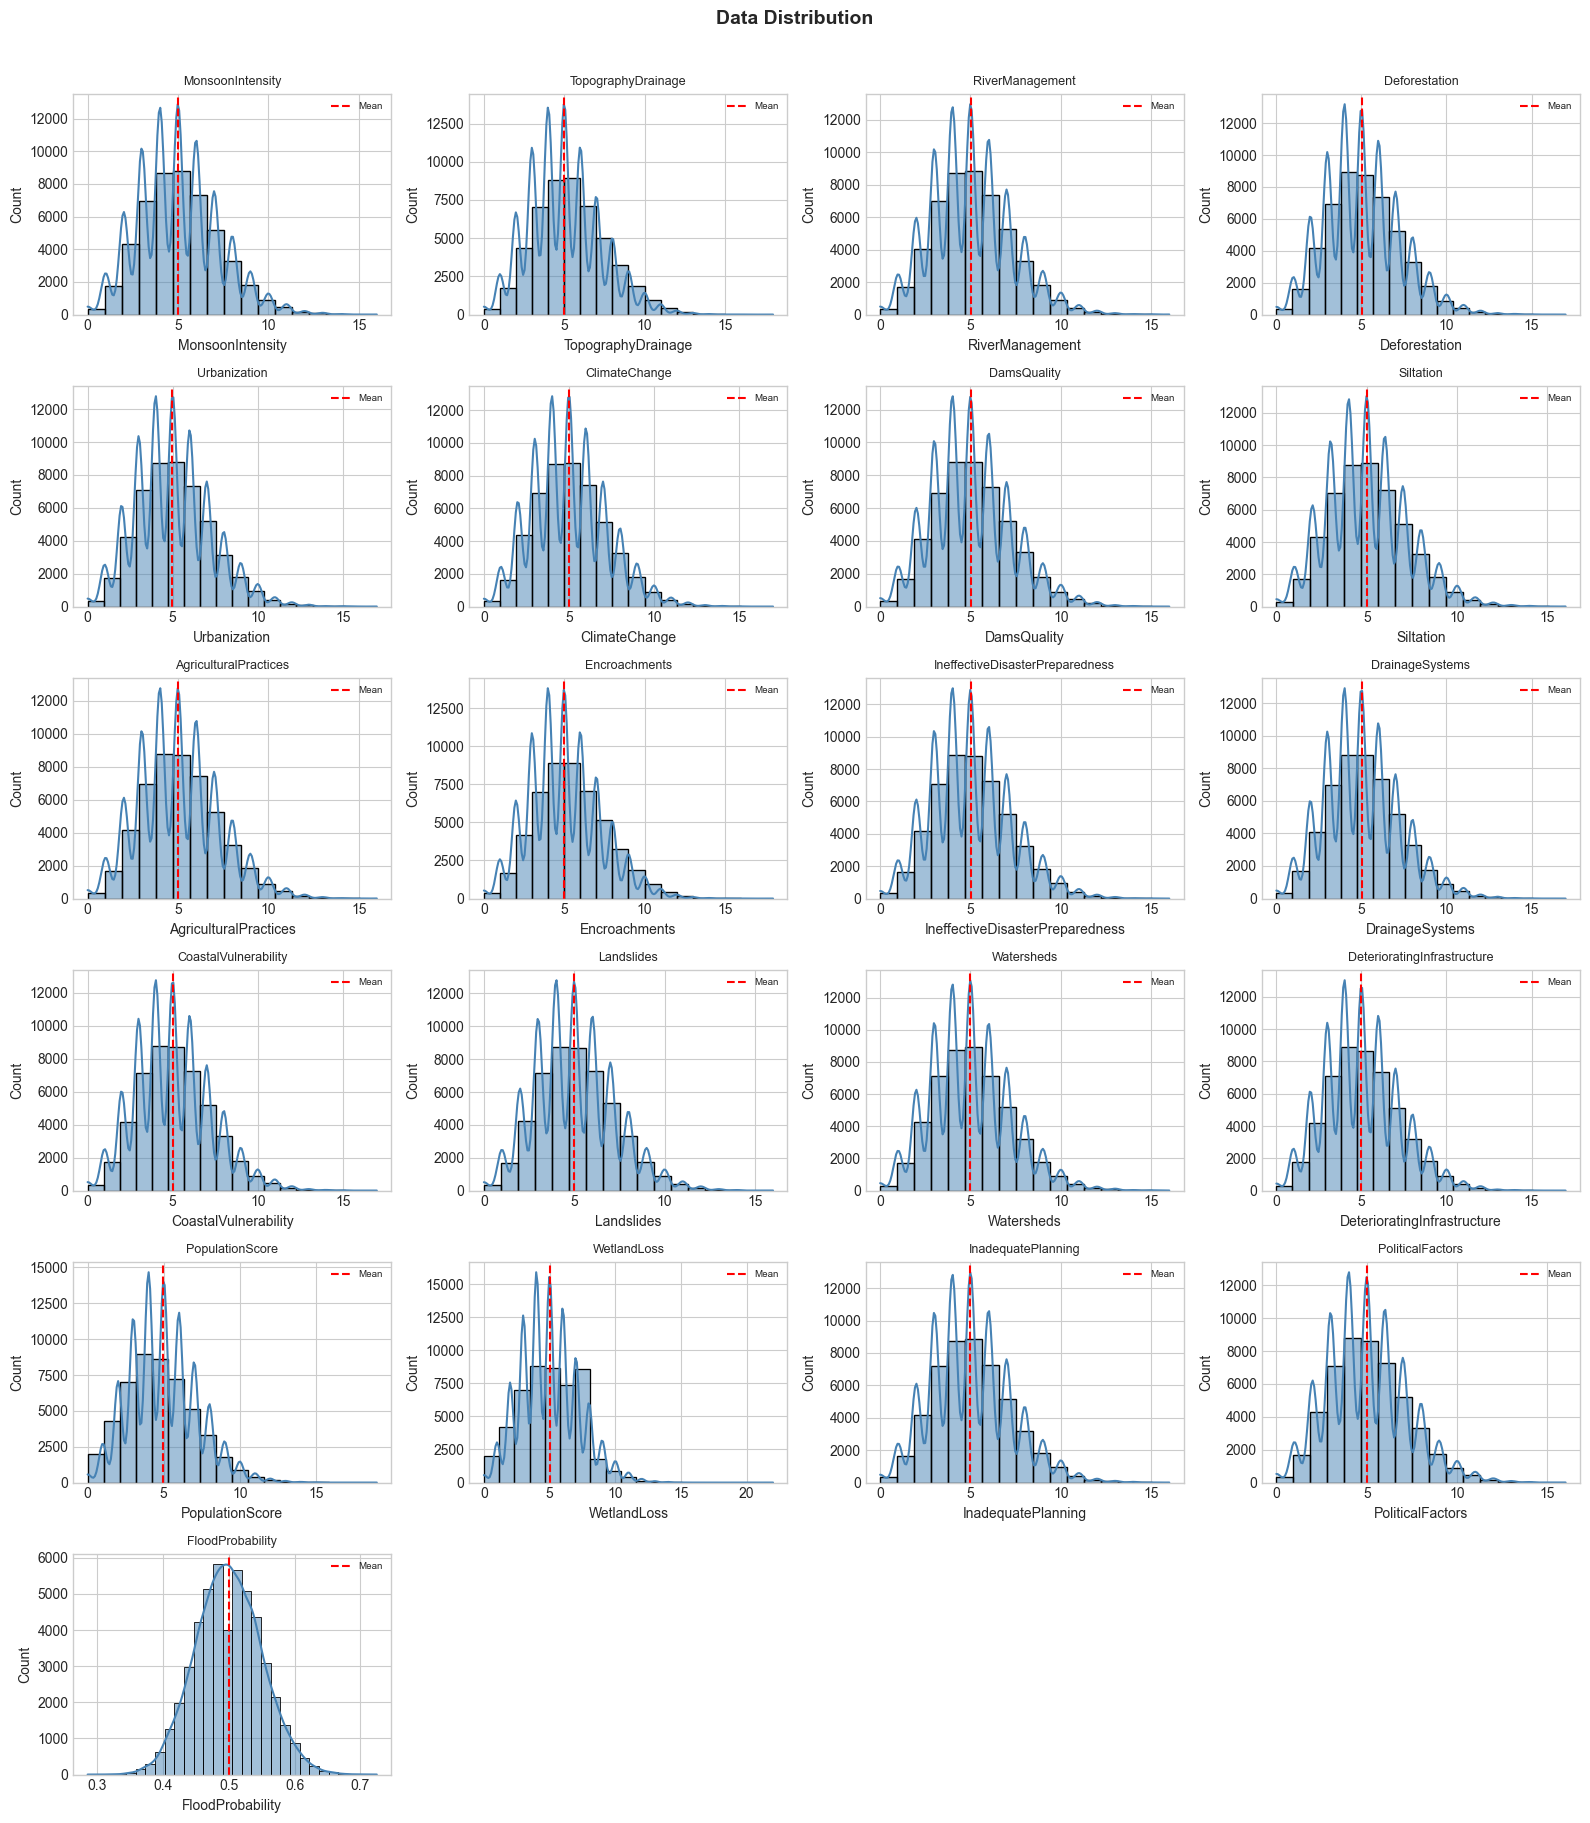

In [63]:
# ============================================================
# CELL 5 — VISUALIZATION: DATA DISTRIBUTION HISTOGRAM
# ============================================================

print("  → Menyimpan histogram distribusi (bins integer-safe)...")

ncols = 4
nrows = ceil(len(df.columns) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3))
axes_flat = axes.flatten()

for i, col in enumerate(df.columns):
    ax = axes_flat[i]
    n_bins = int(min(30, df[col].nunique()))
    sns.histplot(df[col], ax=ax, kde=True, bins=n_bins, color='steelblue')
    ax.axvline(df[col].mean(), color='red', linestyle='--',
               linewidth=1.5, label='Mean')
    ax.set_title(col, fontsize=9)
    ax.legend(fontsize=7)

# Hide empty axes
for j in range(len(df.columns), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle('Data Distribution', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

  CORRELATION ANALYSIS


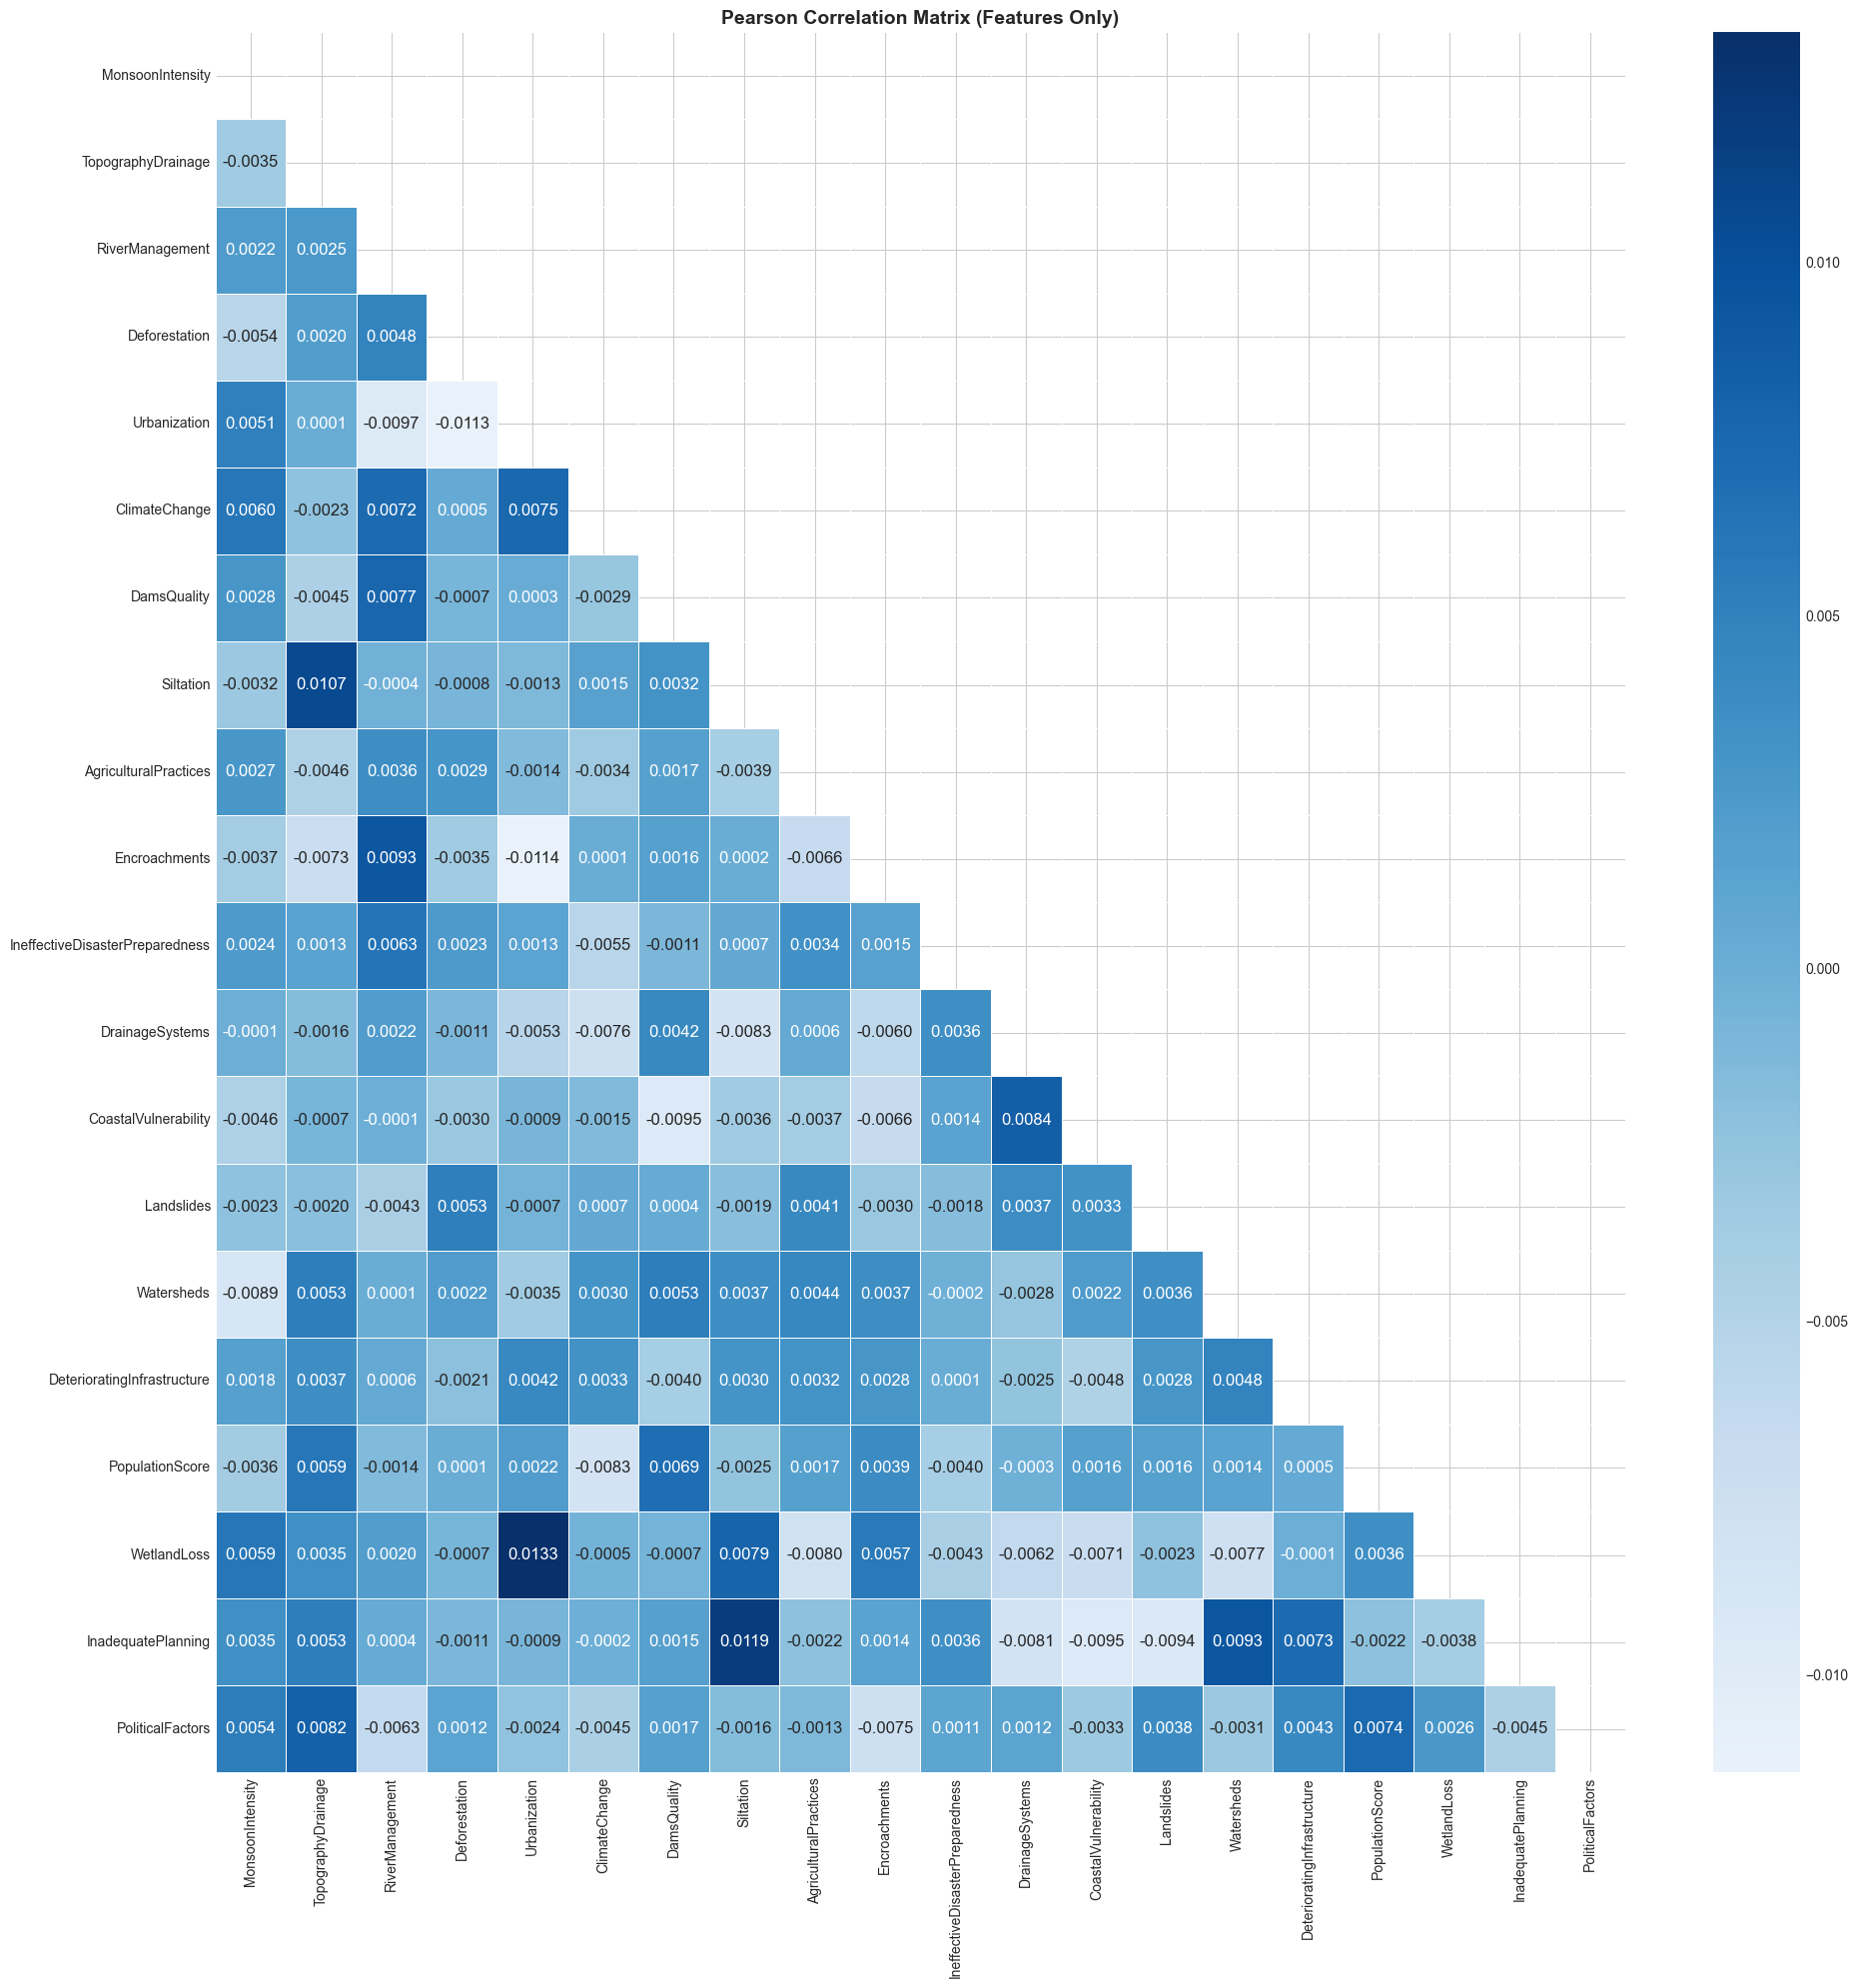

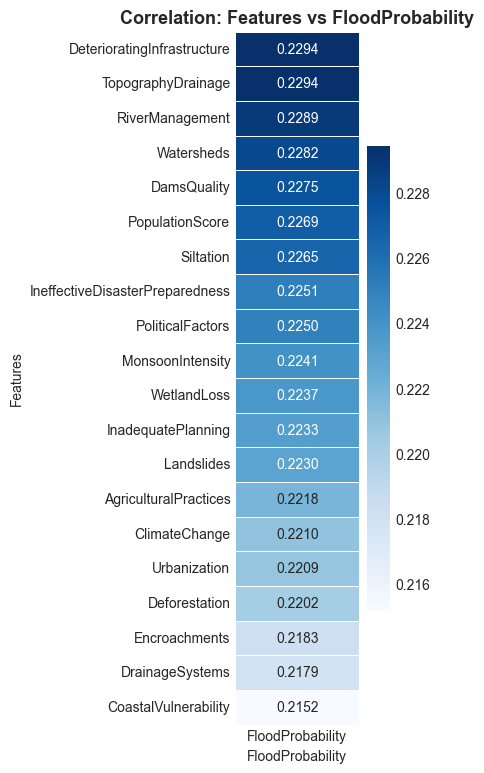

[E] CORRELATION FITUR vs TARGET (Top 5)
  DeterioratingInfrastructure              0.2294
  TopographyDrainage                       0.2294
  RiverManagement                          0.2289
  Watersheds                               0.2282
  DamsQuality                              0.2275

  Catatan: Korelasi yang lebih tinggi menunjukkan hubungan
  lebih kuat antara fitur dan target.


In [62]:
# ============================================================
# CELL 6 — VISUALIZATION: CORRELATION HEATMAP
# ============================================================
print(SEP)
print("  CORRELATION ANALYSIS")
print(SEP)

# ── Full feature-only correlation matrix ──────────────────────────────────────
df_corr = df[FEATURE_COLS].copy()
corr_matrix = df_corr.corr(method='pearson')
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
n_cols = len(FEATURE_COLS)

fig, ax = plt.subplots(figsize=(max(14, n_cols), max(12, n_cols)))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.4f',
    cmap="Blues",
    center=0,
    linewidths=0.5,
    annot_kws={'size': 12},
    ax=ax
)
ax.set_title('Pearson Correlation Matrix (Features Only)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Correlation vs Target: horizontal heatmap (y=fitur, x=target) ─────────────
corr_target = (
    df[FEATURE_COLS + [TARGET_COL]]
    .corr(method='pearson')[TARGET_COL]
    .drop(TARGET_COL)
    .sort_values(ascending=False)
)

# Reshape menjadi (n_fitur, 1) agar bisa dijadikan heatmap
corr_target_df = corr_target.to_frame()   # shape: (n_fitur, 1)

fig, ax = plt.subplots(figsize=(2, max(6, len(FEATURE_COLS) * 0.45)))
sns.heatmap(
    corr_target_df,
    annot=True,
    fmt='.4f',
    cmap='Blues',
    linewidths=0.5,
    annot_kws={'size': 10},
    ax=ax
)
ax.set_title(f'Correlation: Features vs {TARGET_COL}', fontsize=13, fontweight='bold')
ax.set_xlabel(TARGET_COL)
ax.set_ylabel('Features')
ax.tick_params(axis='x', rotation=0)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()

print("[E] CORRELATION FITUR vs TARGET (Top 5)")
for feat, val in corr_target.head(5).items():
    print(f"  {feat:<40} {val:.4f}")

print()
print("  Catatan: Korelasi yang lebih tinggi menunjukkan hubungan")
print("  lebih kuat antara fitur dan target.")
print(SEP)

  OUTLIER ANALYSIS
[D] OUTLIER DETECTION SUMMARY
  Kolom                                       IQR    Z-Score
  ----------------------------------------------------------
  MonsoonIntensity                            686        250
  TopographyDrainage                          711        272
  RiverManagement                             661        260
  Deforestation                               682        271
  Urbanization                                687        297
  ClimateChange                               647        272
  DamsQuality                                 741        283
  Siltation                                   671        278
  AgriculturalPractices                       683        252
  Encroachments                               688        271
  IneffectiveDisasterPreparedness             656        253
  DrainageSystems                             731        283
  CoastalVulnerability                        747        284
  Landslides                        

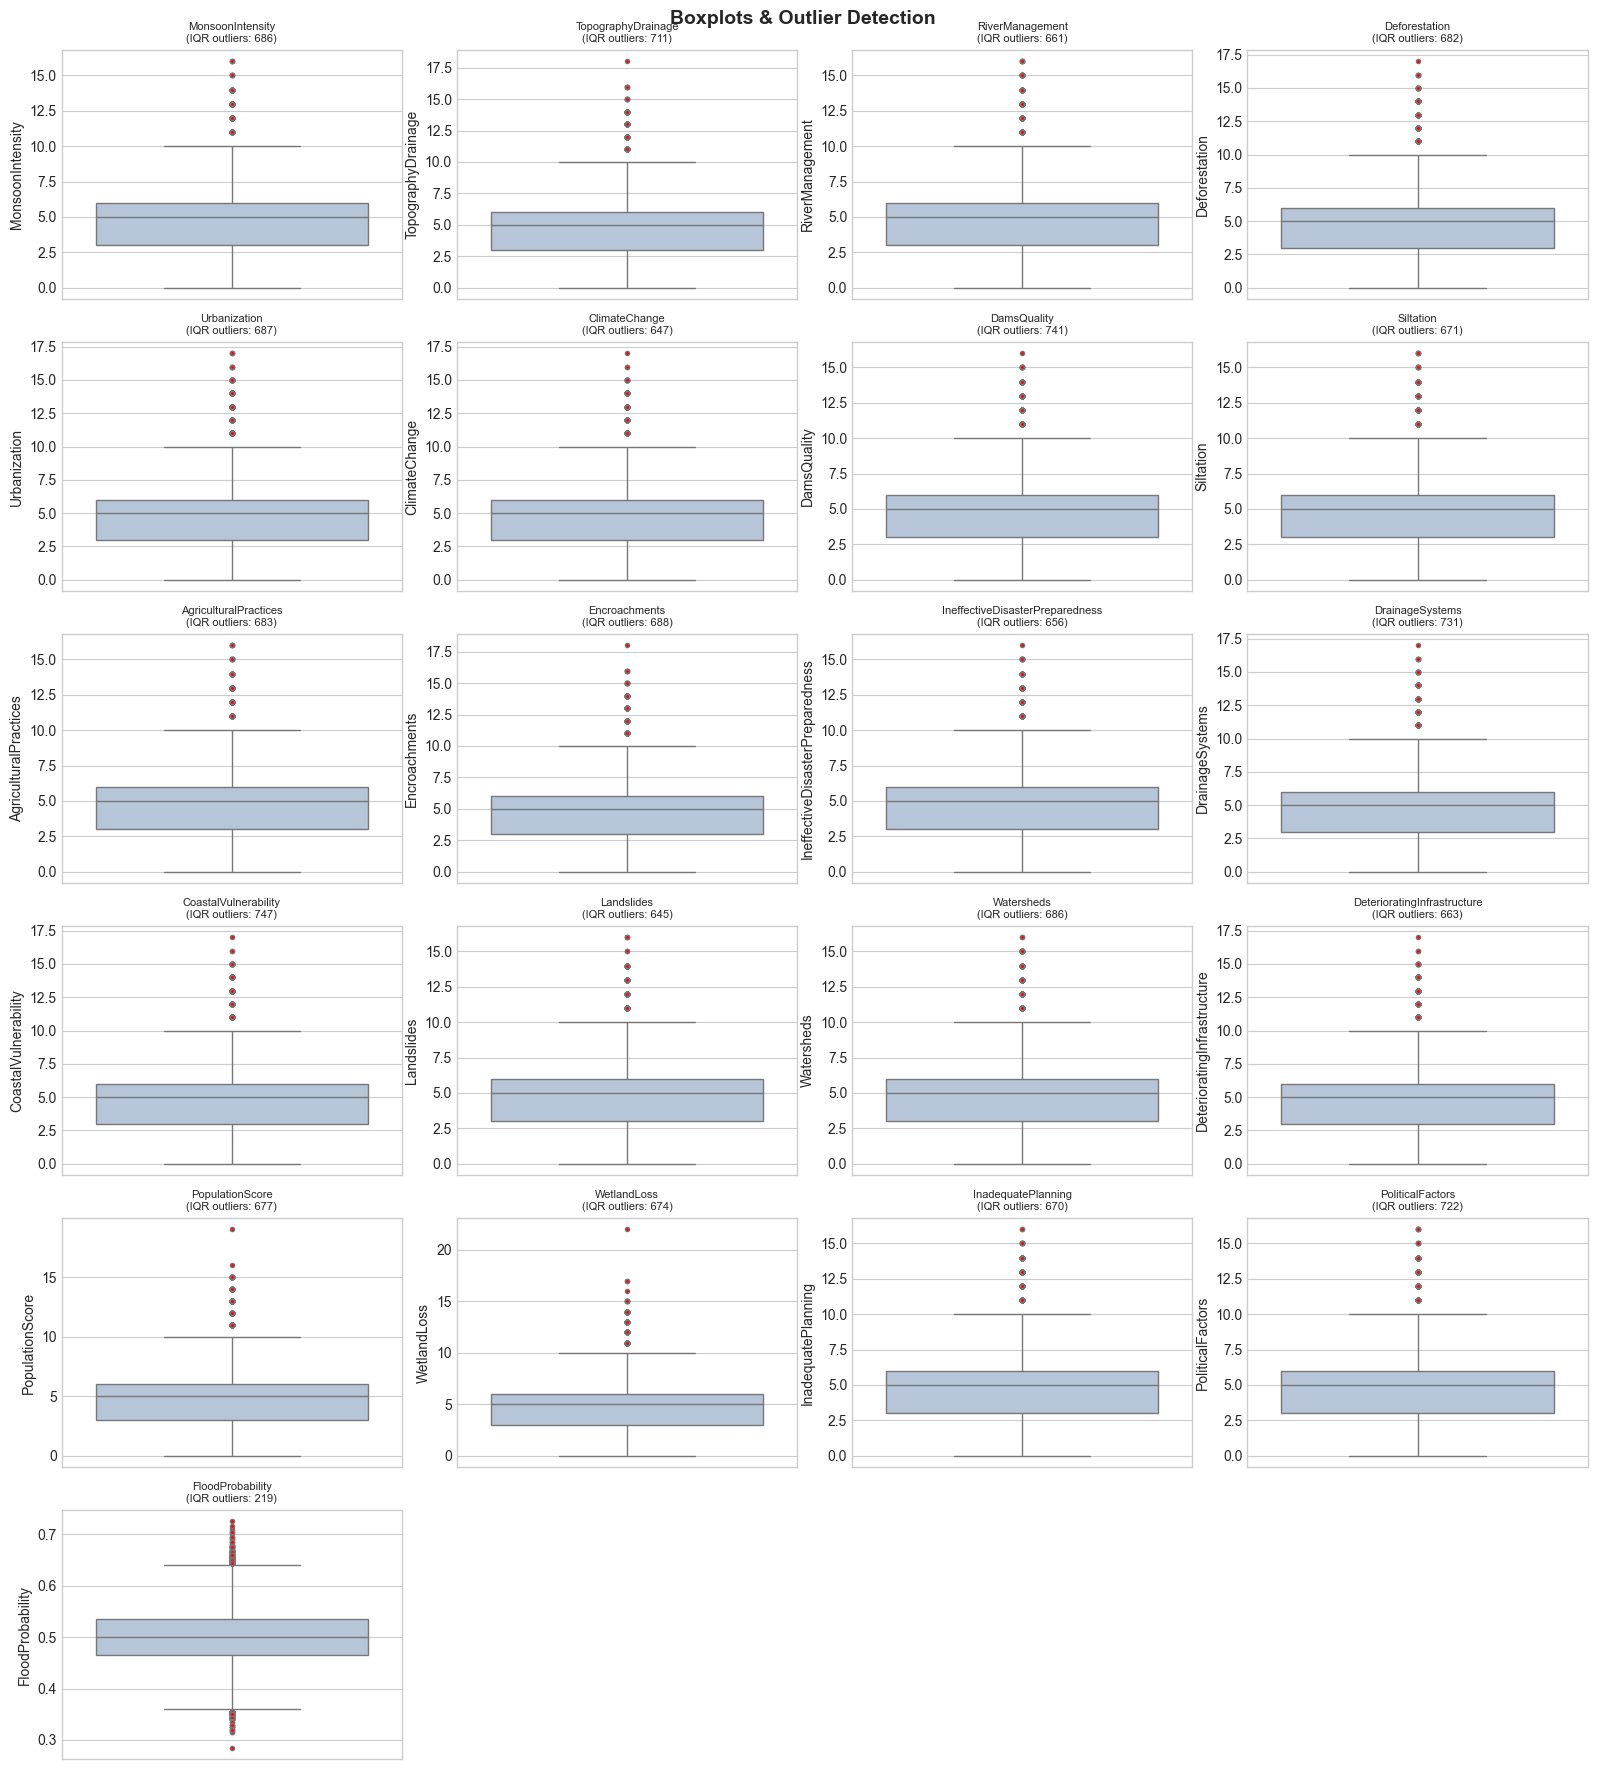


[D] OUTLIER HANDLING DECISION
  Outlier terdeteksi via metode IQR dan Z-score.
  Namun outlier TIDAK dihapus karena:
   • SVR dengan kernel RBF relatif robust terhadap outlier
     dengan tuning C yang tepat.
   • Tree-based model (LightGBM, RandomForest) melakukan
     split berdasarkan threshold/ranking, bukan jarak.
   • Nilai ekstrem bisa merepresentasikan kondisi nyata
     yang relevan untuk prediksi.



In [64]:
# ============================================================
# CELL 7 — VISUALIZATION: BOXPLOT & OUTLIER ANALYSIS
# ============================================================

print(SEP)
print("  OUTLIER ANALYSIS")
print(SEP)
print("[D] OUTLIER DETECTION SUMMARY")

# Compute outliers
outlier_summary = {}
for col in df.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers_iqr = int(((df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)).sum())
    z_scores = np.abs((df[col] - df[col].mean()) / df[col].std())
    outliers_z = int((z_scores > 3).sum())
    outlier_summary[col] = {'IQR': outliers_iqr, 'Z-Score': outliers_z}

header = f"  {'Kolom':<40} {'IQR':>6} {'Z-Score':>10}"
print(header)
print("  " + "-" * 58)
for col, vals in outlier_summary.items():
    print(f"  {col:<40} {vals['IQR']:>6} {vals['Z-Score']:>10}")

# Boxplots
ncols = 4
nrows = ceil(len(df.columns) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3))
axes_flat = axes.flatten()

for i, col in enumerate(df.columns):
    ax = axes_flat[i]
    sns.boxplot(
        y=df[col], ax=ax, color='lightsteelblue',
        flierprops=dict(marker='o', markerfacecolor='red', markersize=3)
    )
    n_out = outlier_summary[col]['IQR']
    ax.set_title(f"{col}\n(IQR outliers: {n_out})", fontsize=8)

for j in range(len(df.columns), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle('Boxplots & Outlier Detection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print()
print("[D] OUTLIER HANDLING DECISION")
print("  Outlier terdeteksi via metode IQR dan Z-score.")
print("  Namun outlier TIDAK dihapus karena:")
print("   • SVR dengan kernel RBF relatif robust terhadap outlier")
print("     dengan tuning C yang tepat.")
print("   • Tree-based model (LightGBM, RandomForest) melakukan")
print("     split berdasarkan threshold/ranking, bukan jarak.")
print("   • Nilai ekstrem bisa merepresentasikan kondisi nyata")
print("     yang relevan untuk prediksi.")
print()
print(SEP)

In [65]:
# ============================================================
# CELL 8 — PREPROCESSING
# ============================================================

X = df[FEATURE_COLS].copy()
y = df[TARGET_COL].copy()

# ── Encoding: check for categorical columns ───────────────────────────────────
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
if cat_cols:
    enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X[cat_cols] = enc.fit_transform(X[cat_cols])
    encoding_note = f"OrdinalEncoder diterapkan pada {len(cat_cols)} kolom: {cat_cols}"
else:
    encoding_note = "tidak diperlukan (semua fitur numerik)"

# ── Imputation: check for missing ────────────────────────────────────────────
missing_total = X.isnull().sum().sum()
if missing_total > 0:
    imp = SimpleImputer(strategy='median')
    X = pd.DataFrame(imp.fit_transform(X), columns=FEATURE_COLS)
    impute_note = f"SimpleImputer(median) diterapkan — {missing_total} nilai diisi"
else:
    impute_note = "tidak diperlukan (tidak ada missing value)"

# ── Train / Test Split ────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

# Reset indices for later numpy indexing
X_train = X_train.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

print(SEP)
print("  PREPROCESSING")
print(SEP)
print(f"  ✓ Encoding  : {encoding_note}")
print(f"  ✓ Imputasi  : {impute_note}")
print("  ✓ Scaling   : SVR → StandardScaler via Pipeline internal")
print("                LightGBM & RandomForest → tidak diperlukan")
print(f"  Train set   : {len(X_train):,} samples  ({int((1-TEST_SIZE)*100)}%)")
print(f"  Test  set   : {len(X_test):,} samples  ({int(TEST_SIZE*100)}%)")
print(SEP)

if len(X_train) > 20_000:
    print("  ⚠ WARNING: Dataset besar — SVR training mungkin memakan waktu lama.")
    print("    Pertimbangkan subsample atau kernel aproksimasi (Nystroem) jika diperlukan.")

  PREPROCESSING
  ✓ Encoding  : tidak diperlukan (semua fitur numerik)
  ✓ Imputasi  : tidak diperlukan (tidak ada missing value)
  ✓ Scaling   : SVR → StandardScaler via Pipeline internal
                LightGBM & RandomForest → tidak diperlukan
  Train set   : 40,000 samples  (80%)
  Test  set   : 10,000 samples  (20%)
  ⚠ WARNING: Dataset besar — SVR training mungkin memakan waktu lama.
    Pertimbangkan subsample atau kernel aproksimasi (Nystroem) jika diperlukan.


In [ ]:
# ============================================================
# CELL 9 — MODEL DEFINITION
# ============================================================

# [1] SVR — wajib Pipeline agar scaling hanya berlaku pada SVR
svr_model = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1))
])

# [2] LightGBM
lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=RANDOM_STATE,
    verbose=-1
)

# [3] Random Forest
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# [4] Ensemble — StackingRegressor (soft average dari ketiga model)
ensemble_model = StackingRegressor(
    estimators=[
        ('svr', svr_model),
        ('lgb', lgb_model),
        ('rf',  rf_model)
    ],
    n_jobs=-1
)

# Dictionary untuk iterasi
MODELS = {
    'SVR':          svr_model,
    'LightGBM':     lgb_model,
    'RandomForest': rf_model,
    'Ensemble':     ensemble_model
}

print(SEP)
print("  MODEL DEFINITION")
print(SEP)
print("  [1] SVR          → Pipeline(StandardScaler → SVR(rbf, C=100))")
print("  [2] LightGBM     → LGBMRegressor(n_est=500, lr=0.05, depth=6)")
print("  [3] RandomForest → RandomForestRegressor(n_est=300)")
print("  [4] Ensemble     → StackingRegressor(SVR + LightGBM + RF)")
print(SEP)

  MODEL DEFINITION
  [1] SVR          → Pipeline(StandardScaler → SVR(rbf, C=100))
  [2] LightGBM     → LGBMRegressor(n_est=500, lr=0.05, depth=6)
  [3] RandomForest → RandomForestRegressor(n_est=300)
  [4] Ensemble     → VotingRegressor(SVR + LightGBM + RF)


In [13]:
# ============================================================
# CELL 10 — TRAINING: REPEATED K-FOLD CROSS VALIDATION
# ============================================================

import time

rkf = RepeatedKFold(
    n_splits=K_FOLDS, n_repeats=N_REPEATS, random_state=RANDOM_STATE
)
total_folds = K_FOLDS * N_REPEATS

cv_summary = []

print(SEP)
print(f"  CROSS VALIDATION — Repeated K-Fold (k={K_FOLDS}, n={N_REPEATS}, total={total_folds})")
print(SEP)

for idx, (name, model) in enumerate(MODELS.items(), 1):
    print(f"\n  [{idx}/{len(MODELS)}] MODEL: {name}")

    if name == 'SVR' and len(X_train) > 15000:
        print("  ⚠ WARNING: SVR bisa lambat pada dataset besar.")

    rmse_list, mae_list, mape_list, r2_list = [], [], [], []

    fold_iter = tqdm(
        rkf.split(X_train),
        total=total_folds,
        desc=f"  Training {total_folds} folds",
        ncols=70
    )

    import sklearn
    from sklearn.base import clone

    for train_idx, val_idx in fold_iter:
        X_f_train = X_train.iloc[train_idx]
        X_f_val   = X_train.iloc[val_idx]
        y_f_train = y_train.iloc[train_idx]
        y_f_val   = y_train.iloc[val_idx]

        m = clone(model)
        m.fit(X_f_train, y_f_train)
        y_pred = m.predict(X_f_val)

        rmse_list.append(float(np.sqrt(mean_squared_error(y_f_val, y_pred))))
        mae_list.append(float(mean_absolute_error(y_f_val, y_pred)))
        mape_val = float(np.mean(np.abs(
            (y_f_val.values - y_pred) /
            np.where(np.abs(y_f_val.values) < 1e-8, 1e-8, np.abs(y_f_val.values))
        )) * 100)
        mape_list.append(mape_val)
        r2_list.append(float(r2_score(y_f_val, y_pred)))

    r2_arr   = np.array(r2_list)
    rmse_arr = np.array(rmse_list)
    mae_arr  = np.array(mae_list)
    mape_arr = np.array(mape_list)

    print(f"\n  R²   per fold : {[round(v, 4) for v in r2_arr[:5]]} ...")
    print(f"  Mean R²       : {r2_arr.mean():.4f}  ±  {r2_arr.std():.4f}")
    print(f"  Mean RMSE     : {rmse_arr.mean():.4f}  ±  {rmse_arr.std():.4f}")
    print(f"  Mean MAE      : {mae_arr.mean():.4f}  ±  {mae_arr.std():.4f}")
    print(f"  Mean MAPE     : {mape_arr.mean():.4f} %  ±  {mape_arr.std():.4f} %")

    cv_summary.append({
        'Model'    : name,
        'R2_mean'  : round(r2_arr.mean(),   4),
        'R2_std'   : round(r2_arr.std(),    4),
        'RMSE_mean': round(rmse_arr.mean(), 4),
        'RMSE_std' : round(rmse_arr.std(),  4),
        'MAE_mean' : round(mae_arr.mean(),  4),
        'MAE_std'  : round(mae_arr.std(),   4),
        'MAPE_mean': round(mape_arr.mean(), 4),
        'MAPE_std' : round(mape_arr.std(),  4),
    })

cv_results = pd.DataFrame(cv_summary)

print(f"\n{SEP}")
print("  RANGKUMAN CROSS VALIDATION")
print(f"  {'Model':<16} {'R²(mean±std)':<24} {'RMSE(mean±std)'}")
for _, row in cv_results.iterrows():
    r2_str   = f"{row['R2_mean']:.4f} ± {row['R2_std']:.4f}"
    rmse_str = f"{row['RMSE_mean']:.4f} ± {row['RMSE_std']:.4f}"
    print(f"  {row['Model']:<16} {r2_str:<24} {rmse_str}")
print()
print("  ✓ Std R² terkecil menunjukkan model paling stabil.")
print(SEP)

  CROSS VALIDATION — Repeated K-Fold (k=10, n=3, total=30)

  [1/4] MODEL: SVR
  ⚠ WARNING: SVR bisa lambat pada dataset besar.


  Training 30 folds: 100%|████████████| 30/30 [00:06<00:00,  4.45it/s]



  R²   per fold : [np.float64(0.5503), np.float64(0.564), np.float64(0.5577), np.float64(0.5424), np.float64(0.5386)] ...
  Mean R²       : 0.5518  ±  0.0087
  Mean RMSE     : 0.0335  ±  0.0004
  Mean MAE      : 0.0260  ±  0.0004
  Mean MAPE     : 5.3954 %  ±  0.0801 %

  [2/4] MODEL: LightGBM


  Training 30 folds: 100%|████████████| 30/30 [00:26<00:00,  1.14it/s]



  R²   per fold : [np.float64(0.9769), np.float64(0.9766), np.float64(0.9744), np.float64(0.9769), np.float64(0.9771)] ...
  Mean R²       : 0.9763  ±  0.0009
  Mean RMSE     : 0.0077  ±  0.0001
  Mean MAE      : 0.0059  ±  0.0001
  Mean MAPE     : 1.1882 %  ±  0.0128 %

  [3/4] MODEL: RandomForest


  Training 30 folds: 100%|████████████| 30/30 [00:53<00:00,  1.79s/it]



  R²   per fold : [np.float64(0.7177), np.float64(0.7146), np.float64(0.7116), np.float64(0.7137), np.float64(0.7155)] ...
  Mean R²       : 0.7157  ±  0.0028
  Mean RMSE     : 0.0267  ±  0.0003
  Mean MAE      : 0.0210  ±  0.0003
  Mean MAPE     : 4.2476 %  ±  0.0496 %

  [4/4] MODEL: Ensemble


  Training 30 folds: 100%|████████████| 30/30 [03:29<00:00,  6.97s/it]


  R²   per fold : [np.float64(0.8229), np.float64(0.824), np.float64(0.8211), np.float64(0.8188), np.float64(0.8201)] ...
  Mean R²       : 0.8218  ±  0.0028
  Mean RMSE     : 0.0211  ±  0.0003
  Mean MAE      : 0.0164  ±  0.0002
  Mean MAPE     : 3.3613 %  ±  0.0451 %

  RANGKUMAN CROSS VALIDATION
  Model            R²(mean±std)             RMSE(mean±std)
  SVR              0.5518 ± 0.0087          0.0335 ± 0.0004
  LightGBM         0.9763 ± 0.0009          0.0077 ± 0.0001
  RandomForest     0.7157 ± 0.0028          0.0267 ± 0.0003
  Ensemble         0.8218 ± 0.0028          0.0211 ± 0.0003

  ✓ Std R² terkecil menunjukkan model paling stabil.


In [14]:
# ============================================================
# CELL 11 — FINAL TRAINING & EVALUATION (TRAIN/TEST SPLIT)
# ============================================================

import time

def compute_metrics(y_true, y_pred):
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae  = float(mean_absolute_error(y_true, y_pred))
    mape = float(np.mean(np.abs(
        (np.array(y_true) - np.array(y_pred)) /
        np.where(np.abs(np.array(y_true)) < 1e-8, 1e-8, np.abs(np.array(y_true)))
    )) * 100)
    r2   = float(r2_score(y_true, y_pred))
    return {'RMSE': rmse, 'MAE': mae, 'MAPE': mape, 'R2': r2}


print(SEP)
print("  TRAINING MODEL")
print(SEP)

predictions = {'train': {}, 'test': {}}
train_metrics_all = {}
test_metrics_all  = {}

for name, model in MODELS.items():
    t0 = time.time()
    model.fit(X_train, y_train)
    elapsed = time.time() - t0

    predictions['train'][name] = model.predict(X_train)
    predictions['test'][name]  = model.predict(X_test)
    print(f"  Melatih {name:<16} ✓ ({elapsed:.2f}s)")

    train_metrics_all[name] = compute_metrics(y_train, predictions['train'][name])
    test_metrics_all[name]  = compute_metrics(y_test,  predictions['test'][name])

print()
print(SEP)
print("  MODEL EVALUATION")
print(SEP)

best_model_name = ''
best_r2 = -float('inf')

for name in MODELS:
    tm = train_metrics_all[name]
    em = test_metrics_all[name]
    gap = tm['R2'] - em['R2']

    if gap < 0.02:
        fit_status = "✓ Tidak ada overfitting signifikan"
        gen_status = "BAIK"
    elif gap < 0.05:
        fit_status = "⚠ Overfitting ringan"
        gen_status = "CUKUP"
    else:
        fit_status = "✗ Overfitting terdeteksi"
        gen_status = "KURANG"

    print(f"\n  [{name}]")
    print("    [Train Set]")
    print(f"      R²   : {tm['R2']:.6f}")
    print(f"      MAE  : {tm['MAE']:.6f}")
    print(f"      RMSE : {tm['RMSE']:.6f}")
    print(f"      MAPE : {tm['MAPE']:.4f} %")
    print("    [Test Set]")
    print(f"      R²   : {em['R2']:.6f}")
    print(f"      MAE  : {em['MAE']:.6f}")
    print(f"      RMSE : {em['RMSE']:.6f}")
    print(f"      MAPE : {em['MAPE']:.4f} %")
    print("    [INTERPRETASI]")
    print(f"    {fit_status}.")
    print(f"    Gap R² (Train − Test) = {gap:.4f}")
    print(f"    ✓ Generalisasi model: {gen_status}")

    if em['R2'] > best_r2:
        best_r2 = em['R2']
        best_model_name = name

print()
print(SEP)
print(f"  BEST MODEL (Test R²): {best_model_name} (R²={best_r2:.4f})")
print(SEP)

  TRAINING MODEL
  Melatih SVR              ✓ (0.17s)
  Melatih LightGBM         ✓ (0.76s)
  Melatih RandomForest     ✓ (1.97s)
  Melatih Ensemble         ✓ (8.13s)

  MODEL EVALUATION

  [SVR]
    [Train Set]
      R²   : 0.572253
      MAE  : 0.025451
      RMSE : 0.032744
      MAPE : 5.2902 %
    [Test Set]
      R²   : 0.565032
      MAE  : 0.025455
      RMSE : 0.032914
      MAPE : 5.2877 %
    [INTERPRETASI]
    ✓ Tidak ada overfitting signifikan.
    Gap R² (Train − Test) = 0.0072
    ✓ Generalisasi model: BAIK

  [LightGBM]
    [Train Set]
      R²   : 0.990263
      MAE  : 0.003886
      RMSE : 0.004940
      MAPE : 0.7827 %
    [Test Set]
      R²   : 0.977209
      MAE  : 0.005745
      RMSE : 0.007534
      MAPE : 1.1510 %
    [INTERPRETASI]
    ✓ Tidak ada overfitting signifikan.
    Gap R² (Train − Test) = 0.0131
    ✓ Generalisasi model: BAIK

  [RandomForest]
    [Train Set]
      R²   : 0.961313
      MAE  : 0.007740
      RMSE : 0.009847
      MAPE : 1.5626 %
    [T

  EVALUATION: ACTUAL VS PREDICTED


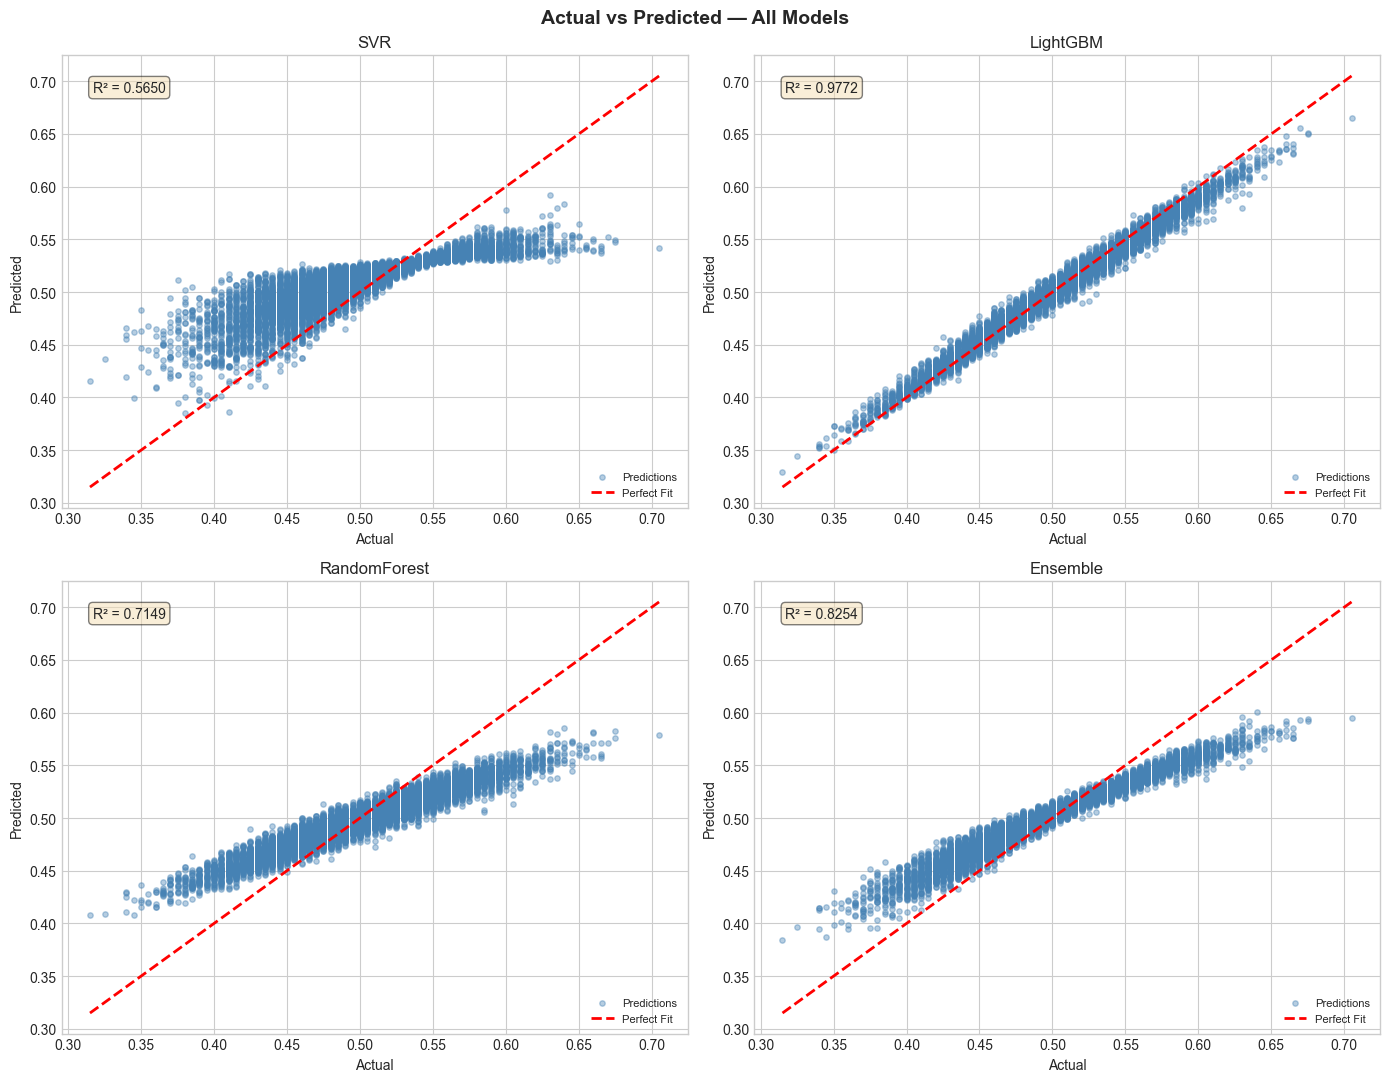

In [66]:
# ============================================================
# CELL 12 — EVALUATION: ACTUAL VS PREDICTED
# ============================================================

print(SEP)
print("  EVALUATION: ACTUAL VS PREDICTED")
print(SEP)

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes_flat = axes.flatten()
model_names = list(MODELS.keys())

for i, name in enumerate(model_names):
    ax = axes_flat[i]
    y_pred_test = predictions['test'][name]
    r2_val = test_metrics_all[name]['R2']

    ax.scatter(y_test, y_pred_test, alpha=0.4, s=15, color='steelblue', label='Predictions')
    mn = float(min(y_test.min(), y_pred_test.min()))
    mx = float(max(y_test.max(), y_pred_test.max()))
    ax.plot([mn, mx], [mn, mx], 'r--', lw=2, label='Perfect Fit')
    ax.text(0.05, 0.92, f'R² = {r2_val:.4f}',
            transform=ax.transAxes, fontsize=10,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.set_title(name)
    ax.legend(fontsize=8)

plt.suptitle('Actual vs Predicted — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print(SEP)

In [ ]:
# ============================================================
# CELL 13 — EVALUATION: RESIDUAL PLOTS
# ============================================================

print(SEP)
print("  EVALUATION: RESIDUAL PLOTS")
print(SEP)

fig, axes = plt.subplots(4, 2, figsize=(14, 20))

for i, name in enumerate(model_names):
    y_pred_test = predictions['test'][name]
    residuals   = y_test.values - y_pred_test

    # Left: Residuals vs Predicted
    ax_left = axes[i][0]
    ax_left.scatter(y_pred_test, residuals, alpha=0.4, s=12, color='steelblue')
    ax_left.axhline(0, color='red', linestyle='--', lw=1.5)
    ax_left.set_title(f'Residuals vs Predicted — {name}')
    ax_left.set_xlabel('Predicted')
    ax_left.set_ylabel('Residuals')

    # Right: Residual distribution
    ax_right = axes[i][1]
    sns.histplot(residuals, kde=True, ax=ax_right, color='steelblue')
    ax_right.axvline(0, color='red', linestyle='--', lw=1.5)
    ax_right.set_title(f'Residual Distribution — {name}')
    ax_right.set_xlabel('Residuals')

plt.tight_layout()
plt.show()
print(SEP)

  EVALUATION: RESIDUAL PLOTS
  → Saved → outputs\figures\06_residual_plots.png


In [ ]:
# ============================================================
# CELL 14 — EVALUATION: LEARNING CURVES
# ============================================================

print(SEP)
print("  EVALUATION: LEARNING CURVES (Overfitting Check)")
print(SEP)
print("  → Menyimpan learning curves...")

# Reduce cv for SVR on large datasets
cv_lc = 3 if len(X_train) > 15000 else 5
train_sizes = np.linspace(0.1, 1.0, 8)
scoring = 'neg_root_mean_squared_error'

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes_flat = axes.flatten()

for i, name in enumerate(model_names):
    model = MODELS[name]
    ax = axes_flat[i]

    train_s, train_sc, val_sc = learning_curve(
        model, X_train, y_train,
        train_sizes=train_sizes,
        cv=cv_lc,
        scoring=scoring,
        n_jobs=-1
    )

    train_mean = -train_sc.mean(axis=1)
    val_mean   = -val_sc.mean(axis=1)
    train_std  = train_sc.std(axis=1)
    val_std    = val_sc.std(axis=1)

    ax.plot(train_s, train_mean, 'o-', color='royalblue', label='Training Score')
    ax.plot(train_s, val_mean,   'o-', color='tomato',    label='Validation Score')
    ax.fill_between(train_s, train_mean - train_std, train_mean + train_std, alpha=0.15, color='royalblue')
    ax.fill_between(train_s, val_mean - val_std,     val_mean + val_std,     alpha=0.15, color='tomato')
    ax.set_title(name)
    ax.set_xlabel('Training Samples')
    ax.set_ylabel('RMSE')
    ax.legend(fontsize=8)

plt.suptitle('Learning Curves — Overfitting Check', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print(SEP)

  EVALUATION: LEARNING CURVES (Overfitting Check)
  → Menyimpan learning curves...
     Saved → outputs\figures\07_learning_curves.png


In [ ]:
# ============================================================
# CELL 15 — FEATURE IMPORTANCE: SHAP ANALYSIS
# ============================================================

print(SEP)
print("  SHAP ANALYSIS")
print(SEP)

background_size   = min(200, len(X_test))
explain_size      = min(300, len(X_test))
explain_size_svr  = min(50,  len(X_test))

X_test_df    = pd.DataFrame(X_test, columns=FEATURE_COLS)
X_background = shap.sample(X_test_df, background_size, random_state=RANDOM_STATE)
X_explain    = X_test_df.iloc[:explain_size]

shap_results = {}

# ── [1] LightGBM — TreeExplainer ─────────────────────────────────────────────
print("\n  [LightGBM — TreeExplainer]")
try:
    explainer_lgb = shap.TreeExplainer(lgb_model)
    shap_vals_lgb = explainer_lgb.shap_values(X_explain, check_additivity=False)
    mean_abs_lgb  = np.abs(shap_vals_lgb).mean(axis=0)
    shap_results['lgb'] = {'vals': shap_vals_lgb, 'mean': mean_abs_lgb}

    print("  Top 5 fitur paling berpengaruh (mean |SHAP|):")
    top5_idx = np.argsort(mean_abs_lgb)[::-1][:5]
    for j in top5_idx:
        print(f"    {FEATURE_COLS[j]:<40} {mean_abs_lgb[j]:.6f}")

    for plot_type, suffix in [('dot', 'summary'), ('bar', 'bar')]:
        plt.figure()
        shap.summary_plot(shap_vals_lgb, X_explain, plot_type=plot_type, show=False)
        plt.tight_layout()
        plt.show()
except Exception as e:
    print(f"  ⚠ LightGBM SHAP error: {e}")

# ── [2] RandomForest — TreeExplainer ─────────────────────────────────────────
print("\n  [RandomForest — TreeExplainer]")
try:
    explainer_rf = shap.TreeExplainer(rf_model)
    shap_vals_rf = explainer_rf.shap_values(X_explain, check_additivity=False)
    mean_abs_rf  = np.abs(shap_vals_rf).mean(axis=0)
    shap_results['rf'] = {'vals': shap_vals_rf, 'mean': mean_abs_rf}

    print("  Top 5 fitur paling berpengaruh (mean |SHAP|):")
    top5_idx = np.argsort(mean_abs_rf)[::-1][:5]
    for j in top5_idx:
        print(f"    {FEATURE_COLS[j]:<40} {mean_abs_rf[j]:.6f}")

    for plot_type, suffix in [('dot', 'summary'), ('bar', 'bar')]:
        plt.figure()
        shap.summary_plot(shap_vals_rf, X_explain, plot_type=plot_type, show=False)
        plt.tight_layout()
        plt.show()
except Exception as e:
    print(f"  ⚠ RandomForest SHAP error: {e}")

# ── [3] SVR — KernelExplainer (subsample kecil) ───────────────────────────────
print(f"\n  [SVR — KernelExplainer] (subsample={explain_size_svr} untuk efisiensi)")
try:
    X_explain_svr = X_test_df.iloc[:explain_size_svr]
    explainer_svr = shap.KernelExplainer(svr_model.predict, X_background)
    shap_vals_svr = explainer_svr.shap_values(X_explain_svr)
    mean_abs_svr  = np.abs(shap_vals_svr).mean(axis=0)
    shap_results['svr'] = {'vals': shap_vals_svr, 'mean': mean_abs_svr}

    print("  Top 5 fitur paling berpengaruh (mean |SHAP|):")
    top5_idx = np.argsort(mean_abs_svr)[::-1][:5]
    for j in top5_idx:
        print(f"    {FEATURE_COLS[j]:<40} {mean_abs_svr[j]:.6f}")

    for plot_type, suffix in [('dot', 'summary'), ('bar', 'bar')]:
        plt.figure()
        shap.summary_plot(shap_vals_svr, X_explain_svr, plot_type=plot_type, show=False)
        plt.tight_layout()
        plt.show()
except Exception as e:
    print(f"  ⚠ SVR SHAP error: {e}")

# ── [4] Ensemble — PermutationExplainer ──────────────────────────────────────
print("\n  [Ensemble — PermutationExplainer]")
try:
    explainer_ens = shap.PermutationExplainer(ensemble_model.predict, X_background)
    shap_vals_ens = explainer_ens(X_explain)
    mean_abs_ens  = np.abs(shap_vals_ens.values).mean(axis=0)
    shap_results['ens'] = {'vals': shap_vals_ens.values, 'mean': mean_abs_ens}

    print("  Top 5 fitur paling berpengaruh (mean |SHAP|):")
    top5_idx = np.argsort(mean_abs_ens)[::-1][:5]
    for j in top5_idx:
        print(f"    {FEATURE_COLS[j]:<40} {mean_abs_ens[j]:.6f}")

    for plot_type, suffix in [('dot', 'summary'), ('bar', 'bar')]:
        plt.figure()
        shap.summary_plot(shap_vals_ens.values, X_explain, plot_type=plot_type, show=False)
        plt.tight_layout()
        plt.show()
except Exception as e:
    print(f"  ⚠ Ensemble SHAP error: {e}")

print(SEP)

  SHAP ANALYSIS

  [LightGBM — TreeExplainer]
  Top 5 fitur paling berpengaruh (mean |SHAP|):
    CoastalVulnerability                     0.008878
    Watersheds                               0.008712
    Encroachments                            0.008636
    PopulationScore                          0.008498
    DrainageSystems                          0.008475
  Saved → outputs\figures\08_shap_lgb_summary.png
  Saved → outputs\figures\08_shap_lgb_bar.png

  [RandomForest — TreeExplainer]
  Top 5 fitur paling berpengaruh (mean |SHAP|):
    TopographyDrainage                       0.005823
    PopulationScore                          0.005803
    PoliticalFactors                         0.005790
    DamsQuality                              0.005615
    IneffectiveDisasterPreparedness          0.005558
  Saved → outputs\figures\08_shap_rf_summary.png
  Saved → outputs\figures\08_shap_rf_bar.png

  [SVR — KernelExplainer] (subsample=50 untuk efisiensi)
  ⚠ SVR SHAP error: property 'featur

Background dataset has 200 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=200 when initializing the masker.
PermutationExplainer explainer: 301it [08:10,  1.65s/it]                         


  Top 5 fitur paling berpengaruh (mean |SHAP|):
    Watersheds                               0.006220
    PopulationScore                          0.006074
    PoliticalFactors                         0.006017
    Siltation                                0.005922
    RiverManagement                          0.005899
  Saved → outputs\figures\08_shap_ens_summary.png
  Saved → outputs\figures\08_shap_ens_bar.png


In [ ]:
# ============================================================
# CELL 16 — MODEL PERSISTENCE
# ============================================================

print(SEP)
print("  MODEL PERSISTENCE")
print(SEP)

for name, model in MODELS.items():
    path = f'{name.lower()}_model.pkl'
    joblib.dump(model, path)
    print(f"  ✓ {name:<16} → {path}")

print(SEP)

  MODEL PERSISTENCE
  ✓ SVR              → outputs\models\svr_model.pkl
  ✓ LightGBM         → outputs\models\lightgbm_model.pkl
  ✓ RandomForest     → outputs\models\randomforest_model.pkl
  ✓ Ensemble         → outputs\models\ensemble_model.pkl


In [20]:
# ============================================================
# CELL 17 — SAMPLE PREDICTION
# ============================================================

print(SEP)
print("  SAMPLE PREDICTION")
print(SEP)

sample     = X_test.iloc[[0]]     # DataFrame slice — kompatibel dengan Pipeline
actual_val = float(y_test.iloc[0])

print("  Input Features:")
for col in FEATURE_COLS:
    print(f"    {col:<40}: {sample[col].values[0]}")

print()
print("  Prediksi Model:")
sample_preds = {}
for name, model in MODELS.items():
    pred = float(model.predict(sample)[0])
    sample_preds[name] = pred
    print(f"    {name:<16}: {pred:.6f}")

print()
print(f"  Nilai Aktual    : {actual_val:.6f}")
print()
print("  Selisih Absolut:")
for name, pred in sample_preds.items():
    diff = abs(actual_val - pred)
    print(f"    {name:<16}: {diff:.6f}")

print(SEP)

  SAMPLE PREDICTION
  Input Features:
    MonsoonIntensity                        : 7
    TopographyDrainage                      : 3
    RiverManagement                         : 4
    Deforestation                           : 4
    Urbanization                            : 5
    ClimateChange                           : 6
    DamsQuality                             : 2
    Siltation                               : 5
    AgriculturalPractices                   : 5
    Encroachments                           : 4
    IneffectiveDisasterPreparedness         : 6
    DrainageSystems                         : 6
    CoastalVulnerability                    : 4
    Landslides                              : 6
    Watersheds                              : 5
    DeterioratingInfrastructure             : 4
    PopulationScore                         : 2
    WetlandLoss                             : 5
    InadequatePlanning                      : 5
    PoliticalFactors                        : 3

 

In [ ]:
# ============================================================
# CELL 18 — EXPORT EVALUATION REPORT
# ============================================================

import io, datetime

buf = io.StringIO()
W = lambda s='': buf.write(s + '\n')

W(SEP)
W("  DATA SCIENCE COMPETITION — EVALUATION REPORT")
W(f"  Generated : {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
W(SEP)

W()
W("  ENVIRONMENT")
W(SEP)
import numpy, pandas, sklearn, lightgbm, shap as _shap
W(f"  NumPy    : {numpy.__version__}")
W(f"  Pandas   : {pandas.__version__}")
W(f"  Sklearn  : {sklearn.__version__}")
W(f"  LightGBM : {lightgbm.__version__}")
W(f"  SHAP     : {_shap.__version__}")

W()
W(SEP)
W("  DATASET OVERVIEW")
W(SEP)
W(f"  File    : {DATA_PATH}")
W(f"  Shape   : {df.shape}")
W(f"  Target  : {TARGET_COL}")
W(f"  Features: {len(FEATURE_COLS)}")

W()
W(SEP)
W("  DATA QUALITY")
W(SEP)
W(f"  Missing values : {df.isnull().sum().sum()}")
W(f"  Duplicates     : {df.duplicated().sum()}")

W()
W(SEP)
W("  CROSS VALIDATION RESULTS")
W(SEP)
W(cv_results.to_string(index=False))

W()
W(SEP)
W("  TRAIN / TEST EVALUATION")
W(SEP)
for name in MODELS:
    tm = train_metrics_all[name]
    em = test_metrics_all[name]
    gap = tm['R2'] - em['R2']
    W(f"  [{name}]")
    W(f"    Train  R²={tm['R2']:.6f}  RMSE={tm['RMSE']:.6f}  MAE={tm['MAE']:.6f}  MAPE={tm['MAPE']:.4f}%")
    W(f"    Test   R²={em['R2']:.6f}  RMSE={em['RMSE']:.6f}  MAE={em['MAE']:.6f}  MAPE={em['MAPE']:.4f}%")
    W(f"    Gap R²={gap:.4f}")
    W()

W(SEP)
W(f"  BEST MODEL (Test R²): {best_model_name}  R²={best_r2:.4f}")
W(SEP)

W()
W(SEP)
W("  TOP 5 SHAP FEATURES PER MODEL")
W(SEP)
shap_names_map = {
    'lgb': 'LightGBM',
    'rf' : 'RandomForest',
    'svr': 'SVR',
    'ens': 'Ensemble'
}
for key, label in shap_names_map.items():
    if key in shap_results:
        mean_arr = shap_results[key]['mean']
        top5 = np.argsort(mean_arr)[::-1][:5]
        W(f"  [{label}]")
        for j in top5:
            W(f"    {FEATURE_COLS[j]:<40} {mean_arr[j]:.6f}")
        W()

W(SEP)

report_text = buf.getvalue()
report_path = 'evaluation_report.txt'
with open(report_path, 'w', encoding='utf-8') as f:
    f.write(report_text)

print(SEP)
print("  ✅  PIPELINE SELESAI")
print(SEP)
print("  File tersimpan di folder yang sama dengan notebook:")
print("    ├── dataset.csv")
print("    ├── notebook.ipynb")
print("    ├── evaluation_report.txt")
print("    ├── svr_model.pkl")
print("    ├── lightgbm_model.pkl")
print("    ├── randomforest_model.pkl")
print("    └── ensemble_model.pkl")
print(SEP)

  ✅  PIPELINE SELESAI
  Output tersimpan di  : outputs/
    figures/ → 14+ file visualisasi
    models/  → 4 model (.pkl)
    reports/ → evaluation_report.txt

  Daftar Figures:
    01_missing_duplicate.png
    02_histograms.png
    03_correlation_heatmap.png
    04_boxplots.png
    05_actual_vs_predicted.png
    06_residual_plots.png
    07_learning_curves.png
    08_shap_ens_bar.png
    08_shap_ens_summary.png
    08_shap_lgb_bar.png
    08_shap_lgb_summary.png
    08_shap_rf_bar.png
    08_shap_rf_summary.png

  → Saved → outputs\reports\evaluation_report.txt
